In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from pathlib import Path

# 設定路徑 (根據你的資料夾結構)
ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_smoking_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

# 建立輸出資料夾
for p in [FIG_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# 讀取清理後的資料
df = pd.read_csv(PROCESSED_PATH)

# 定義群組名稱方便後續畫圖
df['Sex_Label'] = df['WhatIsYourSex'].map({1.0: 'Female', 2.0: 'Male'})


# 1. 準備統計數據
group_stats = df.groupby('Sex_Label')['Smoking_Status'].agg(['sum', 'count'])
# 為了計算 Difference = Male - Female，我們先取出數據
n_male = group_stats.loc['Male', 'count']
s_male = group_stats.loc['Male', 'sum']
n_female = group_stats.loc['Female', 'count']
s_female = group_stats.loc['Female', 'sum']

p_male = s_male / n_male
p_female = s_female / n_female
obs_diff = p_male - p_female

# 2. Two-proportion z-test
# count = [成功數1, 成功數2], nobs = [樣本數1, 樣本數2]
count = [s_male, s_female]
nobs = [n_male, n_female]
z_stat, p_val = proportions_ztest(count, nobs)

# 3. 95% Confidence Interval for Difference
ci_low, ci_upp = confint_proportions_2indep(s_male, n_male, s_female, n_female, method='wald')

# 4. 建立摘要表 (Summary Table)
summary_table = pd.DataFrame({
    'Metric': ['Sample Size (n)', 'Smokers (count)', 'Proportion (p-hat)'],
    'Male': [n_male, s_male, f"{p_male:.2%}"],
    'Female': [n_female, s_female, f"{p_female:.2%}"]
})

print("--- 統計結果 ---")
print(f"Observed Difference (Male-Female): {obs_diff:.4f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"95% CI for Difference: [{ci_low:.4f}, {ci_upp:.4f}]")

# 儲存摘要表
summary_table.to_csv(TAB_DIR / "02_smoking_inference_summary.csv", index=False)
display(summary_table)




--- 統計結果 ---
Observed Difference (Male-Female): 0.0443
Z-statistic: 6.3601
P-value: 2.0161e-10
95% CI for Difference: [0.0306, 0.0579]


,Metric,Male,Female
0,Sample Size (n),6420,6605
1,Smokers (count),1405,1153
2,Proportion (p-hat),21.88%,17.46%


C:\Users\user\AppData\Local\Temp\ipykernel_17024\2355042513.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')
C:\Users\user\AppData\Local\Temp\ipykernel_17024\2355042513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')


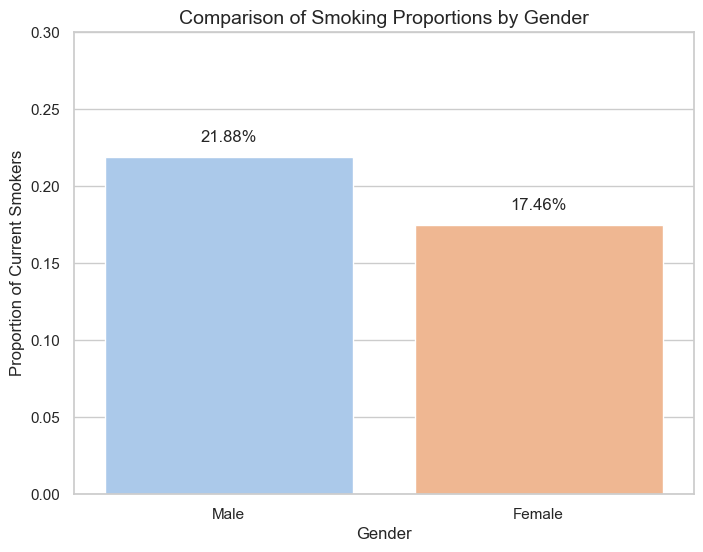

In [ ]:
# 設定圖表風格
sns.set_theme(style="whitegrid")
# 圖 1: 分組長條圖
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')
plt.title('Comparison of Smoking Proportions by Gender', fontsize=14)
plt.ylabel('Proportion of Current Smokers')
plt.xlabel('Gender')
plt.ylim(0, 0.3)

# 在長條圖上標註比例
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', fontsize=12)

plt.savefig(FIG_DIR / "02_proportion_barplot.png")
plt.show()

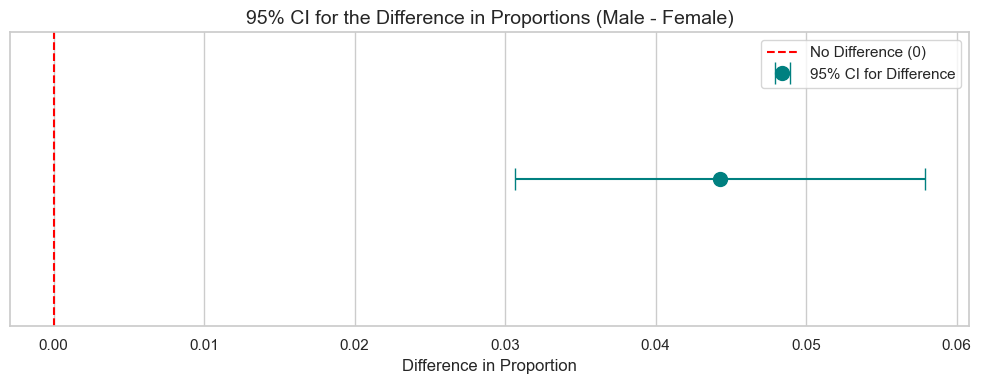

In [ ]:
# 圖 2: 信賴區間圖 (CI Plot)
plt.figure(figsize=(10, 4))
plt.errorbar(obs_diff, 0, xerr=[[obs_diff - ci_low], [ci_upp - obs_diff]], 
             fmt='o', markersize=10, capsize=8, color='teal', label='95% CI for Difference')
plt.axvline(x=0, color='red', linestyle='--', label='No Difference (0)')
plt.title('95% CI for the Difference in Proportions (Male - Female)', fontsize=14)
plt.xlabel('Difference in Proportion')
plt.yticks([]) # 隱藏 Y 軸
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "03_difference_ci_plot.png")
plt.show()